In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_MANE_251104.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()

filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

# min_range = -500
# max_range = +0

anno = (
    anno
    .filter(
        (pl.col('MANE_CDS') == False) &
        (pl.col('non_MANE_CDS') == False) &
        (pl.col('VEP_CDS') == False) &

        # filter_expression &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0) &
        #     (pl.col('consequence_splice_region_variant') == 0) &
        #     (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
        #     (pl.col('consequence_splice_donor_region_variant') == 0) &
        #     (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        # ) &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0)
        #     (pl.col('consequence_start_retained_variant') == 0) &
        #     (pl.col('consequence_start_lost') == 0)
        # ) &
        
        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

gene_length,TSS,gpn_score,promoterai,dist_to_tss,delta_score,Strand,loftee_hc,gpn_star_llr_calibrated_mean,verphylop,region,mamphylop,absplice_dna_max,cadd_raw,absplice2_max,promoterai_abs,esmscoremissense,pangolin_score,gene_name,abexp_min,id,am_pathogenicity
i64,i64,f32,f32,i64,f32,cat,i8,f64,f32,str,f32,f32,f32,f32,f32,f32,f32,str,f64,str,f32
235427,169362534,-1.5,0.0,165367,0.0,"""-""",0,0.153293,0.217,"""ENSG00000081479""",0.774,0.001,0.466688,0.000033,0.0,0.0,0.0,"""LRP2""",-0.006063,"""chr2:169197167:T:G""",0.0
235427,169362534,-0.63,0.0,158242,0.01,"""-""",0,1.684965,0.291,"""ENSG00000081479""",0.085,0.003,0.104863,0.000116,0.0,0.0,0.0,"""LRP2""",-0.026342,"""chr2:169204292:A:T""",0.0
115828,169031324,-1.64,0.0,793,0.0,"""-""",0,-1.212965,0.023,"""ENSG00000073734""",0.015,0.001,0.326902,0.000033,0.0,0.0,0.0,"""ABCB11""",-0.005501,"""chr2:169030531:C:T""",0.0
115828,169031324,-4.15,0.0,120499,0.0,"""-""",0,-1.479978,0.341,"""ENSG00000073734""",0.327,0.0,0.554549,0.0,0.0,0.0,0.0,"""ABCB11""",-0.019354,"""chr2:168910825:T:G""",0.0
115828,169031324,0.08,0.0,24150,0.0,"""-""",0,-0.238119,0.193,"""ENSG00000073734""",0.19,0.001,-0.070862,0.000033,0.0,0.0,0.0,"""ABCB11""",-0.005501,"""chr2:169007174:C:T""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
26847,27496838,-1.06,0.0,29323,0.0,"""+""",0,-0.362401,-0.276,"""ENSG00000084734""",-0.293,0.0,-0.024889,0.0,0.0,0.0,0.0,"""GCKR""",null,"""chr2:27526161:C:A""",0.0
26847,27496838,-1.41,0.0,28041,0.0,"""+""",0,0.407678,0.009,"""ENSG00000084734""",-0.009,0.0,0.579763,0.0,0.0,0.0,0.0,"""GCKR""",null,"""chr2:27524879:T:C""",0.0
12613,30136123,-1.49,0.0,14610,0.0,"""+""",0,0.516636,-0.263,"""ENSG00000204614""",-0.263,0.0,0.145777,0.0,0.0,0.0,0.0,"""TRIM40""",null,"""chr6:30150733:A:C""",0.0


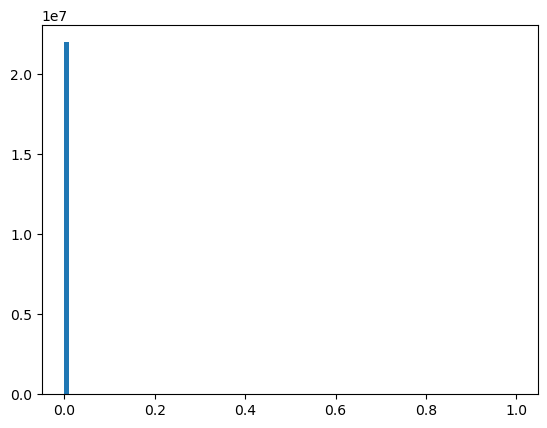

In [4]:
plt.hist(anno['am_pathogenicity'], bins=100)
plt.show()

In [5]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]),
        anno_score_count = pl.len().over(["region", "annotation"])
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count')
    )

    # Filter based on category
    .filter(
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])
    )
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank,anno_score_count,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i64,f64,f64,u64,f64
"""chr2:169197167:T:G""","""ENSG00000081479""","""cadd_raw""",0.466688,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.466688,57501.0,82215,0.699398
"""chr2:169204292:A:T""","""ENSG00000081479""","""cadd_raw""",0.104863,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.104863,27548.0,82215,0.335073
"""chr2:169030531:C:T""","""ENSG00000073734""","""cadd_raw""",0.326902,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.326902,25103.0,43046,0.583167
"""chr2:168910825:T:G""","""ENSG00000073734""","""cadd_raw""",0.554549,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.554549,33272.0,43046,0.772941
"""chr2:169007174:C:T""","""ENSG00000073734""","""cadd_raw""",-0.070862,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,-0.070862,7957.0,43046,0.184849
…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:27526161:C:A""","""ENSG00000084734""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1652.5,11919,0.138644
"""chr2:27524879:T:C""","""ENSG00000084734""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1652.5,11919,0.138644
"""chr6:30150733:A:C""","""ENSG00000204614""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1761.0,7636,0.230618


In [6]:
ctdf = melted_anno.select(['id', 'region']).unique()['region'].value_counts()
ctdf

region,count
str,u64
"""ENSG00000134873""",54098
"""ENSG00000019186""",9602
"""ENSG00000091181""",30146
"""ENSG00000136011""",64924
"""ENSG00000109062""",11278
…,…
"""ENSG00000171714""",193399
"""ENSG00000165699""",20867
"""ENSG00000107863""",50142


In [7]:
ctdf['count'].describe()

statistic,value
str,f64
"""count""",649.0
"""null_count""",0.0
"""mean""",33893.070878
"""std""",51083.075293
"""min""",2310.0
"""25%""",8679.0
"""50%""",17779.0
"""75%""",41166.0
"""max""",549478.0


In [8]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [10]:
n_steps = 100
or_threshold_anno = 0.95
or_threshold_pheno = 0.99

# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    "ptile_cutoff": [or_threshold_anno + (i/n_steps)*(1-or_threshold_anno) for i in range(n_steps)]
})

# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('ptile_cutoff')

or_df.write_parquet(f'/home/dnanexus/data_dir/odds_ratio_non_coding_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""cadd_raw""","""ENSG00000196712""","""NF1""","""cystatin_c_int""",0.95,31,2767,547,53099,1.087556
"""cadd_raw""","""ENSG00000118762""","""PKD2""","""cystatin_c_int""",0.95,13,778,159,14950,1.571114
"""cadd_raw""","""ENSG00000244734""","""HBB""","""red_blood_cell_erythrocyte_cou…",0.95,6,154,24,3361,5.456169
"""cadd_raw""","""ENSG00000110245""","""APOC3""","""creactive_protein_int""",0.95,0,130,26,2463,0.0
"""cadd_raw""","""ENSG00000042429""","""MED17""","""mean_corpuscular_volume_int""",0.95,7,414,75,7799,1.758229
…,…,…,…,…,…,…,…,…,…
"""absplice2_max""","""ENSG00000155827""","""RNF20""","""mean_corpuscular_haemoglobin_i…",0.99975,0,4,81,7450,0.0
"""absplice2_max""","""ENSG00000159899""","""NPR2""","""trunk_fatfree_mass_int""",0.99975,0,2,55,4336,0.0
"""absplice2_max""","""ENSG00000196739""","""COL27A1""","""arm_fatfree_mass_left_int""",0.99975,0,7,371,34642,0.0


In [11]:
max_rank_df = gp_lazy.group_by('label').agg(max_rank = pl.col('annotation_score_dircor_rank').max()).collect(engine='streaming')
max_rank_df

label,max_rank
str,f64
"""Pangolin""",274739.5
"""GPN-Star""",549477.0
"""Mammalian PhyloP""",549400.0
"""CADD Raw""",549478.0
"""AbSplice (max)""",274739.5
"""SpliceAI""",274739.5
"""AbSplice2 (max)""",274739.5
"""GPN-MSA""",549477.0
"""Vertebrate PhyloP""",549478.0


## Plotting

In [12]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/odds_ratio_non_coding_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')
print('unique percentile cutoffs:', or_df['ptile_cutoff'].n_unique())

plt_df_tmp = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['ptile_cutoff', 'annotation']),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['ptile_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['ptile_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['ptile_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'ptile_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('ptile_cutoff')
)

plt_df_tmp

unique percentile cutoffs: 200


annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""gpn_star_llr_calibrated_mean""",0.95,1176,1.125428,1.192704,0.016836,1.225703,1.159705,"""#942c80""","""GPN-Star"""
"""verphylop""",0.95,1176,1.082587,1.1517,0.016598,1.184233,1.119167,"""#942c80""","""Vertebrate PhyloP"""
"""absplice_dna_max""",0.95,1158,1.038161,1.182124,0.027583,1.236186,1.128063,"""#28a745""","""AbSplice (max)"""
"""gpn_score""",0.95,1176,1.128484,1.224366,0.018358,1.260347,1.188384,"""#942c80""","""GPN-MSA"""
"""absplice2_max""",0.95,1162,1.031605,1.102272,0.017938,1.13743,1.067114,"""#28a745""","""AbSplice2 (max)"""
…,…,…,…,…,…,…,…,…,…
"""mamphylop""",0.99975,808,0.0,1.715999,0.299369,2.302762,1.129235,"""#942c80""","""Mammalian PhyloP"""
"""gpn_score""",0.99975,1085,0.0,2.641374,0.433832,3.491684,1.791064,"""#942c80""","""GPN-MSA"""
"""gpn_star_llr_calibrated_mean""",0.99975,1108,0.0,1.911118,0.26578,2.432047,1.390188,"""#942c80""","""GPN-Star"""


In [13]:
cutoffs_df = cutoffs_lazy.collect()

# Prepare the lazy frame once
melted_lazy = melted_anno.lazy()

# 1. Use a list comprehension to run all queries
results = [
    melted_lazy
    .filter(pl.col('annotation_score_dircor_ptile') > cutoff)
    .group_by('annotation')
    .agg(
        pl.col('id').n_unique().alias('n_vars_above')
    )
    .with_columns(
        pl.lit(cutoff).alias('ptile_cutoff')
    )
    .collect(engine='streaming')

    # Iterate directly over the cutoff values
    for cutoff in cutoffs_df.get_column("ptile_cutoff")
]

# 2. Concatenate the results
if results:
    counts_df = pl.concat(results).sort('ptile_cutoff')
else:
    # Handle the case where there were no cutoffs, creating an empty DataFrame
    # with the correct schema
    counts_df = pl.DataFrame(schema={
        "annotation": melted_anno.get_column("annotation").dtype,
        "n_vars_above": pl.UInt32, # n_unique() returns UInt32
        "ptile_cutoff": cutoffs_df.get_column("ptile_cutoff").dtype
    })

plt_df = plt_df_tmp.join(counts_df, on=['annotation', 'ptile_cutoff'], how='inner')
plt_df

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,n_vars_above
str,f64,u64,f64,f64,f64,f64,f64,str,str,u64
"""absplice_dna_max""",0.95,1158,1.038161,1.182124,0.027583,1.236186,1.128063,"""#28a745""","""AbSplice (max)""",669637
"""verphylop""",0.95,1176,1.082587,1.1517,0.016598,1.184233,1.119167,"""#942c80""","""Vertebrate PhyloP""",1086334
"""gpn_star_llr_calibrated_mean""",0.95,1176,1.125428,1.192704,0.016836,1.225703,1.159705,"""#942c80""","""GPN-Star""",1087050
"""pangolin_score""",0.95,1162,1.027247,1.121409,0.022676,1.165854,1.076963,"""#28a745""","""Pangolin""",837932
"""absplice2_max""",0.95,1162,1.031605,1.102272,0.017938,1.13743,1.067114,"""#28a745""","""AbSplice2 (max)""",894507
…,…,…,…,…,…,…,…,…,…,…
"""pangolin_score""",0.99975,1097,0.0,5.434067,0.627229,6.663435,4.204698,"""#28a745""","""Pangolin""",4781
"""absplice_dna_max""",0.99975,1090,0.0,3.803485,0.451255,4.687945,2.919024,"""#28a745""","""AbSplice (max)""",4750
"""gpn_score""",0.99975,1085,0.0,2.641374,0.433832,3.491684,1.791064,"""#942c80""","""GPN-MSA""",5779


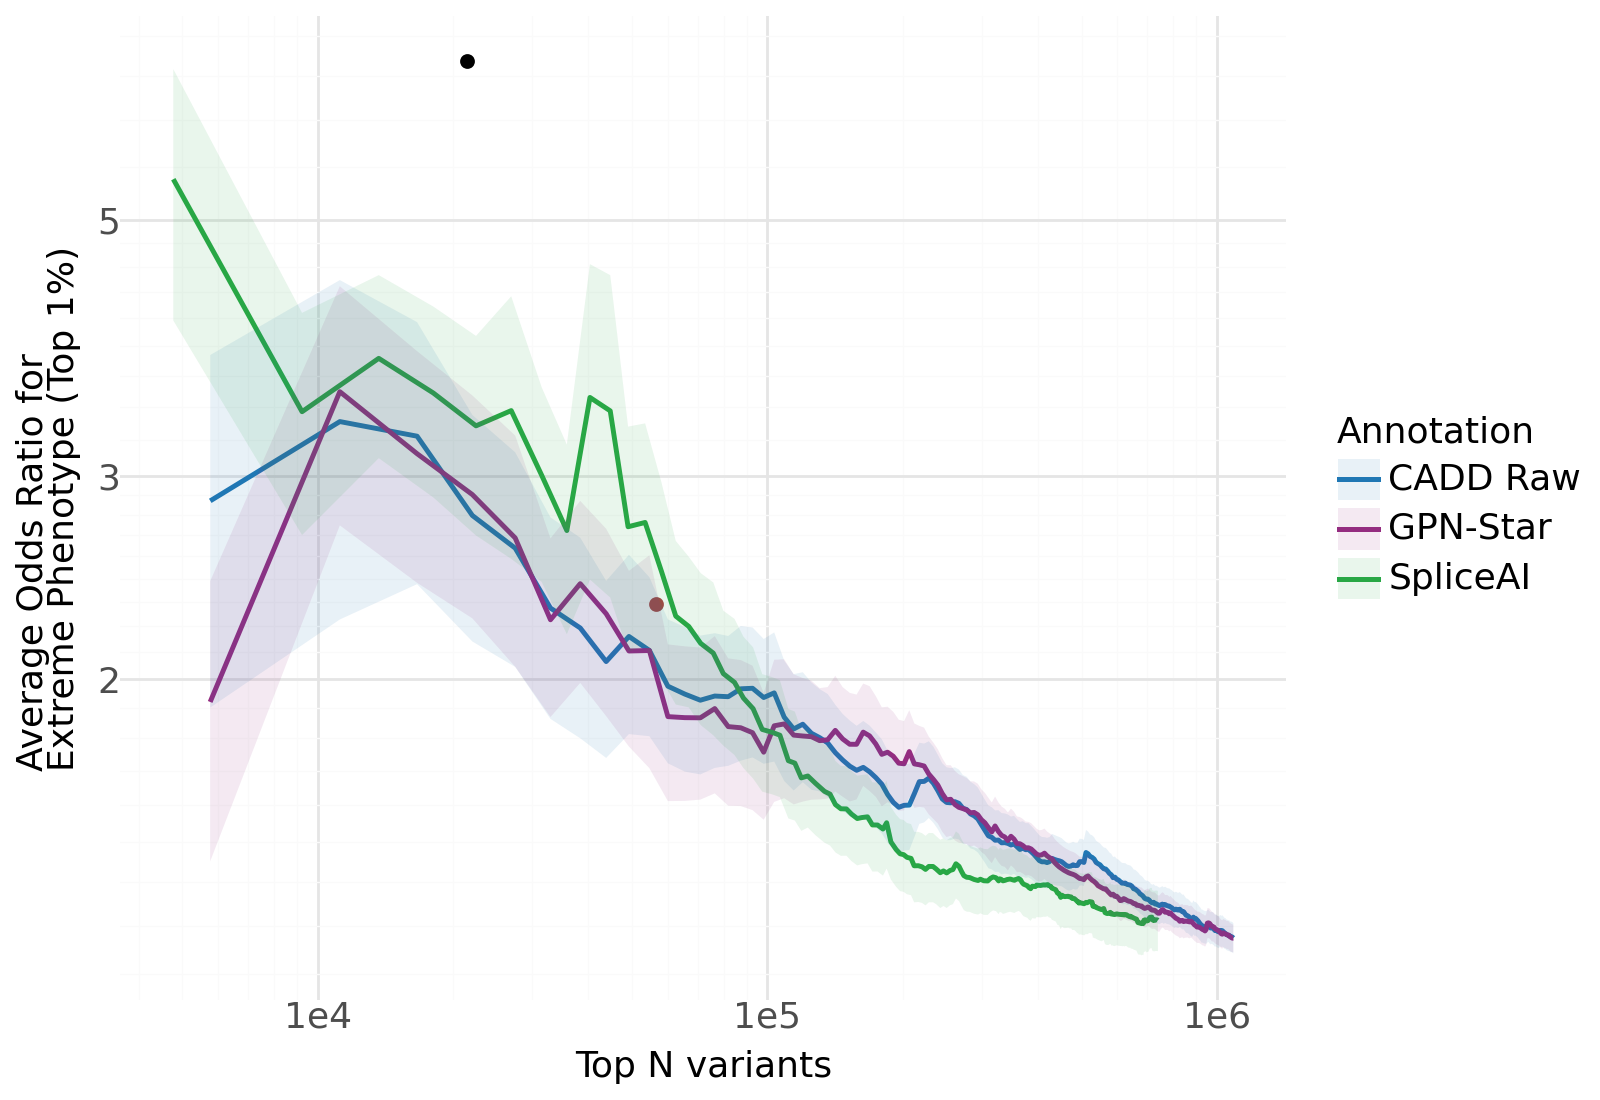

In [22]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))

am_lof_df = pl.DataFrame({
    'annotation': ['loftee_coding', 'am_0.8_coding', 'loftee_all', 'am_0.8_all'],
    'n_vars': [21519, 56609, 21519, 56609],  # Check these numbers for "all"!!!
    'mean_or': [6.874422, 2.323273, 9.998645, 3.628273],
    'median_or': [3.04127, 1.770242, 3.573782, 2.027029],
})

(
    ggplot(
        plt_df.filter(
            pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'delta_score'])
        ),
        aes(x='n_vars_above', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='loftee_coding'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='am_0.8_coding'), aes(x='n_vars', y='mean_or'), color='#AA4344', size=2)
    # + geom_hline(aes(yintercept=am_lof_df['mean_or'][am_lof_df['annotation'] == 'loftee_coding']), linetype='dashed', color='black', size=0.75)
    # + geom_hline(aes(yintercept=am_lof_df['mean_or'][am_lof_df['annotation'] == 'am_0.8_coding']), linetype='dashed', color='#AA4344', size=0.75)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio for\nExtreme Phenotype (Top 1%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_log10()
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

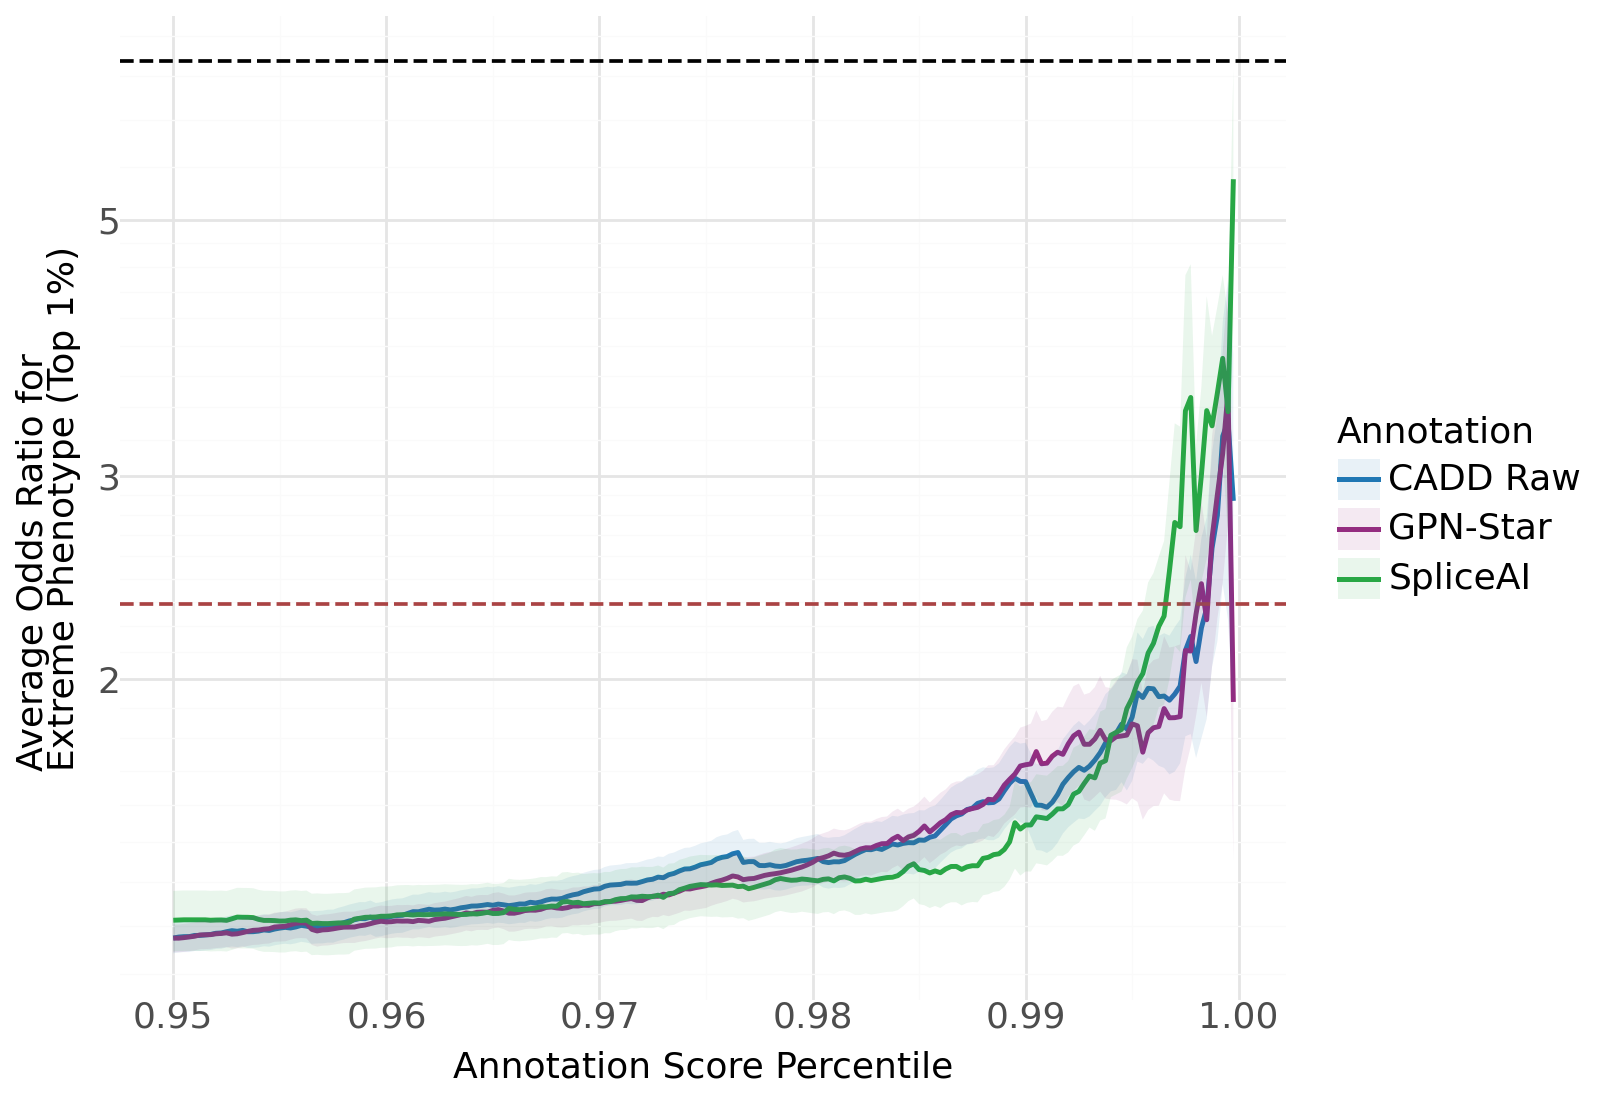

In [15]:
(
    ggplot(
        plt_df.filter(
            pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'delta_score'])
        ),
        aes(x='ptile_cutoff', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_hline(aes(yintercept=am_lof_or_mean['loftee_coding']), linetype='dashed', color='black', size=0.75)
    + geom_hline(aes(yintercept=am_lof_or_mean['am_0.8_coding']), linetype='dashed', color='#AA4344', size=0.75)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio for\nExtreme Phenotype (Top 1%)",
        x="Annotation Score Percentile",
        color="Annotation",
        fill="Annotation",
    )
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

## Cross AM > 0.8

In [16]:
# find the first ptile_cutoff where avg_odds_ratio crosses the AM threshold
threshold = am_lof_or_mean['am_0.8_coding']
# threshold = 2

crossing = (
    plt_df
    .select(['annotation', 'label', 'ptile_cutoff', 'avg_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .filter(pl.col('avg_odds_ratio') >= threshold)
    .sort(['label', 'ptile_cutoff'])
    .group_by('label')
    .agg([
        pl.first('annotation').alias('annotation'),
        pl.first('ptile_cutoff').alias('ptile_cross'),
        pl.first('avg_odds_ratio').alias('avg_or_at_cross'),
        pl.first('std_ci_upper').alias('std_ci_upper_at_cross'),
        pl.first('std_ci_lower').alias('std_ci_lower_at_cross'),
    ])
    .sort('ptile_cross', nulls_last=True)
)

print("threshold =", threshold)
crossing

threshold = 2.323273


label,annotation,ptile_cross,avg_or_at_cross,std_ci_upper_at_cross,std_ci_lower_at_cross
str,str,f64,f64,f64,f64
"""Pangolin""","""pangolin_score""",0.9965,2.352438,2.709979,1.994897
"""AbSplice2 (max)""","""absplice2_max""",0.99675,2.389376,2.73221,2.046541
"""SpliceAI""","""delta_score""",0.99675,2.481922,2.964238,1.999607
"""AbSplice (max)""","""absplice_dna_max""",0.99725,2.392531,2.745145,2.039916
"""GPN-Star""","""gpn_star_llr_calibrated_mean""",0.99825,2.420113,2.854998,1.985228
"""CADD Raw""","""cadd_raw""",0.99875,2.59786,3.146123,2.049597
"""GPN-MSA""","""gpn_score""",0.9995,2.35357,2.961627,1.745514


In [17]:
# For each annotation in `crossing`, count unique ids in `melted_anno` with annotation_score_dircor_ptile > ptile_cross

cross_lf = crossing.select(['annotation', 'ptile_cross']).unique().lazy()

counts_df = (
    melted_anno.lazy()
    .join(cross_lf, on='annotation', how='inner')
    .filter(pl.col('annotation_score_dircor_ptile') > pl.col('ptile_cross'))
    .group_by(['annotation', 'ptile_cross'])
    .agg(
        n_ids_above = pl.col('id').n_unique()
    )
    .collect(engine='streaming')
    .sort('ptile_cross')
)

# Attach labels (if present) for easier interpretation
counts_df = counts_df.join(crossing.select(['annotation', 'label']).unique(), on='annotation', how='left')

counts_df = (
    counts_df
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
)
counts_df

annotation,ptile_cross,n_ids_above,label,color,label_right
str,f64,u64,str,str,str
"""pangolin_score""",0.9965,62608,"""Pangolin""","""#28a745""","""Pangolin"""
"""delta_score""",0.99675,58120,"""SpliceAI""","""#28a745""","""SpliceAI"""
"""absplice2_max""",0.99675,58297,"""AbSplice2 (max)""","""#28a745""","""AbSplice2 (max)"""
"""absplice_dna_max""",0.99725,47843,"""AbSplice (max)""","""#28a745""","""AbSplice (max)"""
"""gpn_star_llr_calibrated_mean""",0.99825,38366,"""GPN-Star""","""#942c80""","""GPN-Star"""
"""cadd_raw""",0.99875,27501,"""CADD Raw""","""#1f77b4""","""CADD Raw"""
"""gpn_score""",0.9995,11198,"""GPN-MSA""","""#942c80""","""GPN-MSA"""


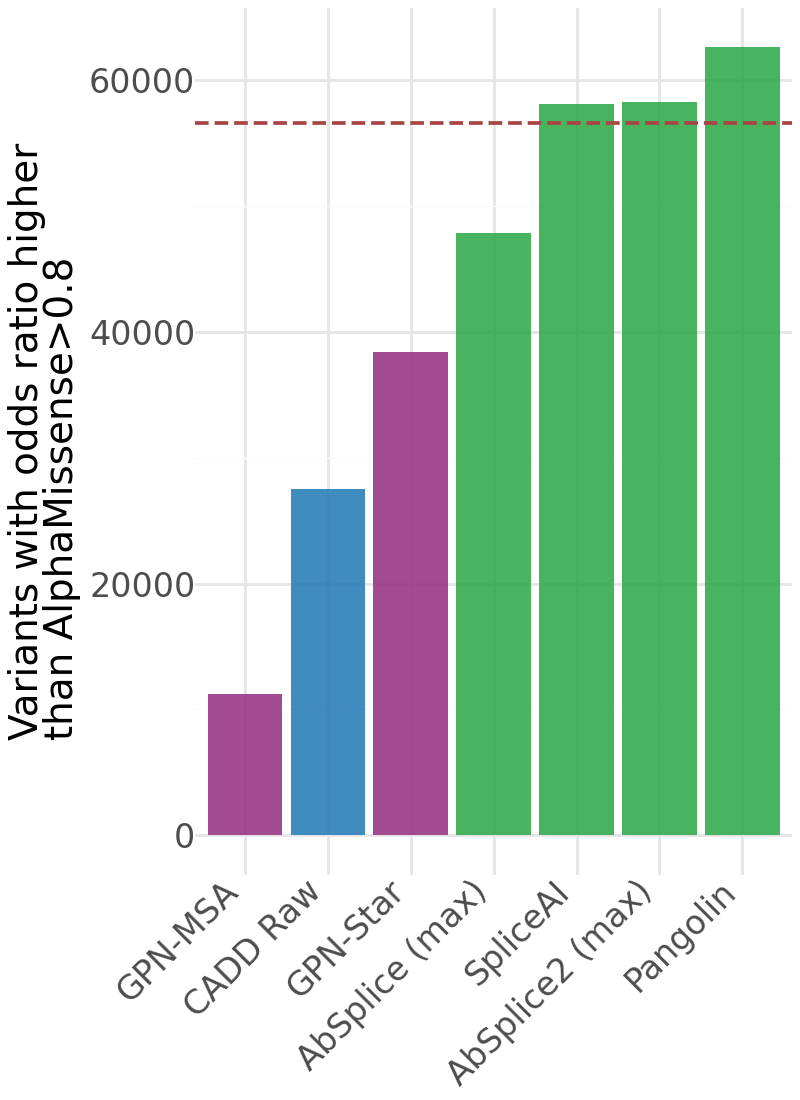

In [18]:
n_vars = {
    'loftee': 21519,
    'am_0.8_coding': 56609
}

plot_df = counts_df.to_pandas()
plot_df['label'] = pd.Categorical(
    plot_df['label'],
    categories=plot_df.sort_values('n_ids_above', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(plot_df['label'], plot_df['color']))

(
    ggplot(
        plot_df,
        aes(x='label', y='n_ids_above', fill='label')
    )
    + geom_bar(stat='identity', alpha=0.85)
    + geom_hline(aes(yintercept=n_vars['am_0.8_coding']), linetype='dashed', color='#AA4344', size=0.75)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        y="Variants with odds ratio higher\nthan AlphaMissense>0.8",
        x="",
    )
    # + scale_y_log10()
    + theme(
        figure_size=(4, 5.5),
        legend_position = 'none',
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=12),
        axis_title=element_text(size=14),
        legend_text=element_text(size=12),
        legend_title=element_text(size=12),
    )
)